# IMDB Sentiment Analysis using Deep Neural Networks (Binary Classification)

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

print("All libraries imported successfully.")

All libraries imported successfully.


In [2]:
# Hyperparameters
NUM_WORDS  = 10000   # vocabulary size (top 10k frequent words)
MAX_LEN    = 250     # pad/truncate each review to 250 tokens

# Load IMDB dataset (50k reviews: 25k train, 25k test)
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=NUM_WORDS)

print(f"Training samples : {len(x_train)}")
print(f"Test samples     : {len(x_test)}")
print(f"Sample label     : {y_train[0]}  (1=positive, 0=negative)")
print(f"Sample review    : {x_train[0][:10]} ...")

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training samples : 25000
Test samples     : 25000
Sample label     : 1  (1=positive, 0=negative)
Sample review    : [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65] ...


In [3]:
# Pad shorter reviews with zeros; truncate longer ones to MAX_LEN
x_train = pad_sequences(x_train, maxlen=MAX_LEN, padding='post', truncating='post')
x_test  = pad_sequences(x_test,  maxlen=MAX_LEN, padding='post', truncating='post')

print(f"x_train shape : {x_train.shape}")  # (25000, 250)
print(f"x_test  shape : {x_test.shape}")   # (25000, 250)

x_train shape : (25000, 250)
x_test  shape : (25000, 250)


In [4]:
# ── Model Architecture ──────────────────────────────────────────────
#  Embedding → BiLSTM(64) → BiLSTM(32) → Dense(1, sigmoid)
# ────────────────────────────────────────────────────────────────────

model = Sequential([
    # 1. Embedding layer — maps word indices to dense vectors
    Embedding(input_dim=NUM_WORDS, output_dim=128, input_shape=(MAX_LEN,)),

    # 2. First Bidirectional LSTM — returns full sequence for next layer
    Bidirectional(LSTM(64, return_sequences=True)),
    Dropout(0.3),

    # 3. Second Bidirectional LSTM — returns final hidden state only
    Bidirectional(LSTM(32)),
    Dropout(0.3),

    # 4. Output layer — sigmoid → probability of positive sentiment
    Dense(1, activation='sigmoid')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:103: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 250, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 250, 128)       │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 250, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,420,097 (5.42 MB)

 Trainable params: 1,420,097 (5.42 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
# Binary cross-entropy is the standard loss for binary classification
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

print("Model compiled successfully.")

Model compiled successfully.


In [6]:
# Early stopping stops training if val_loss stops improving (saves time)
early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

history = model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.2,   # 20% of training data used for validation
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 16s 55ms/step - accuracy: 0.7256 - loss: 0.5391 - val_accuracy: 0.7950 - val_loss: 0.4551
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 49ms/step - accuracy: 0.8714 - loss: 0.3251 - val_accuracy: 0.8548 - val_loss: 0.3502
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 50ms/step - accuracy: 0.9194 - loss: 0.2223 - val_accuracy: 0.8556 - val_loss: 0.3547
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 48ms/step - accuracy: 0.9423 - loss: 0.1668 - val_accuracy: 0.8536 - val_loss: 0.3828


In [7]:
loss, acc = model.evaluate(x_test, y_test, batch_size=128, verbose=0)

print(f"Test accuracy : {acc:.4f}")
print(f"Test loss     : {loss:.4f}")

Test accuracy : 0.8365
Test loss     : 0.3804


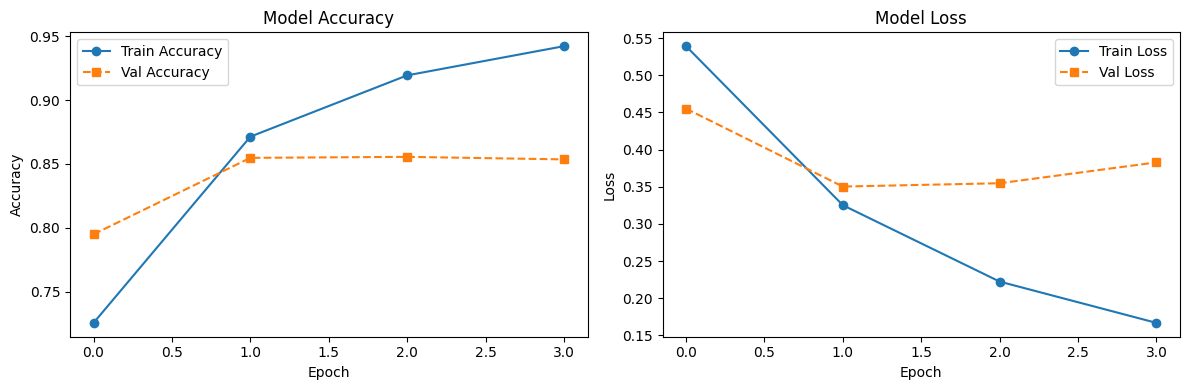

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Accuracy plot
axes[0].plot(history.history['accuracy'],
             linestyle='-', marker='o', label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'],
             linestyle='--', marker='s', label='Val Accuracy')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# Loss plot
axes[1].plot(history.history['loss'],
             linestyle='-', marker='o', label='Train Loss')
axes[1].plot(history.history['val_loss'],
             linestyle='--', marker='s', label='Val Loss')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step
Confusion Matrix:
 [[11216  1284]
 [ 2803  9697]]


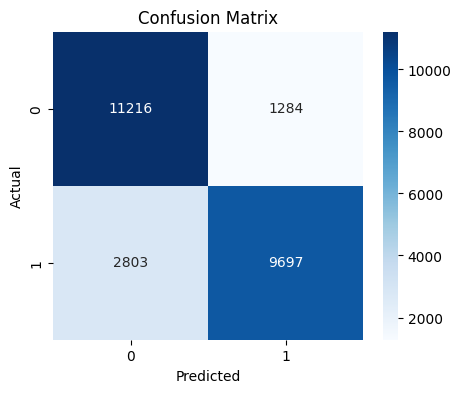


Classification Report:

              precision    recall  f1-score   support

           0       0.80      0.90      0.85     12500
           1       0.88      0.78      0.83     12500

    accuracy                           0.84     25000
   macro avg       0.84      0.84      0.84     25000
weighted avg       0.84      0.84      0.84     25000



In [9]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Predict on test data
y_pred_prob = model.predict(x_test)
y_pred = (y_pred_prob > 0.5).astype("int32")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:\n", cm)

# Plot
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))